##### Telco Customer Churn - Exploratory Data Analysis

#####  Import Libraries

In [3]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import os

##### Load the raw dataset

In [5]:
DATA_PATH = r"c:\Users\HP\Desktop\Telco-Customer-Churn-Prediction-Model\data\raw\Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully from: {DATA_PATH}")


Dataset loaded successfully from: c:\Users\HP\Desktop\Telco-Customer-Churn-Prediction-Model\data\raw\Telco-Customer-Churn.csv


In [6]:
#  Display First 5 Rows


df.head()

#  Dataset Shape

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(df.shape)

#  Column Information

print("Columns in the dataset:")
print(df.columns.tolist())

#  Data Types

df.dtypes

Rows: 7043
Columns: 21
(7043, 21)
Columns in the dataset:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

##### Data Cleaning

In [7]:
# Missing Values

missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

#  Duplicate Records

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

#  Summary Statistics

df.describe(include='all').T


# Inspect the target column distribution
if 'Churn' in df.columns:
    churn_distribution = df['Churn'].value_counts(dropna=False)
    print(churn_distribution)
    print("\nPercentage distribution:")
    print(df['Churn'].value_counts(normalize=True, dropna=False) * 100)
else:
    print("The target column 'Churn' was not found in the dataset.")


Series([], dtype: int64)
Number of duplicate rows: 0
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage distribution:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [8]:
# Fix incorrect data types

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
# Handle missing values

df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
# Check for duplicates again

df.duplicated().sum()

np.int64(0)

In [11]:
# Save the cleaned dataset

import os

print(os.getcwd())

df.to_csv("../data/processed/telco_customer_churn_clean.csv", index=False)


c:\Users\HP\Desktop\Telco-Customer-Churn-Prediction-Model\notebooks


#### Feature Engineering

Feature engineering creates new variables from existing data to capture patterns that may improve churn prediction.

##### Feature 1: Tenure Group

Group customers based on how long they've been with the company.

In [12]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["New", "Regular", "Loyal", "Very Loyal"]
)

Business reason:

New customers often churn more than long-term customers.

##### Feature 2: Average Monthly Spend

In [13]:
df["AvgMonthlySpend"] = (
    df["TotalCharges"] / df["tenure"].replace(0, 1)
)

Business reason:

Measures how much a customer spends on average each month.

##### Feature 3: Number of Services

Count how many services each customer subscribes to.

In [14]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["NumServices"] = (
    df[service_columns]
    .replace({
        "Yes": 1,
        "No": 0,
        "No internet service": 0,
        "No phone service": 0
    })
    .sum(axis=1)
)

C:\Users\HP\AppData\Local\Temp\ipykernel_5864\422377067.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


Business reason:

Customers using more services may be less likely to leave.

##### Feature 4: Long-Term Contract

In [15]:
df["IsLongTermContract"] = (
    df["Contract"]
    .isin(["One year", "Two year"])
    .astype(int)
)

Business reason:

Long-term contracts generally reduce churn.

##### Feature 5: Family Support

In [16]:
df["HasFamilySupport"] = (
    (
        (df["Partner"] == "Yes") |
        (df["Dependents"] == "Yes")
    )
).astype(int)

Business reason:

Customers with partners or dependents may have different retention behavior.

In [17]:
df[[
    "TenureGroup",
    "AvgMonthlySpend",
    "NumServices",
    "IsLongTermContract",
    "HasFamilySupport"
]].head()

,TenureGroup,AvgMonthlySpend,NumServices,IsLongTermContract,HasFamilySupport
0,New,29.850000,1,0,1
1,Loyal,55.573529,3,1,0
2,New,54.075000,3,0,0
3,Loyal,40.905556,3,1,0
4,New,75.825000,1,0,0


In [18]:
df.to_csv(
    "../data/processed/telco_customer_churn_features.csv",
    index=False
)

| Feature            | Why it was created                                  |
| ------------------ | --------------------------------------------------- |
| TenureGroup        | Groups customers by loyalty period.                 |
| AvgMonthlySpend    | Measures average spending per month.                |
| NumServices        | Counts subscribed services.                         |
| IsLongTermContract | Identifies customers on longer contracts.           |
| HasFamilySupport   | Combines partner and dependents into one indicator. |


#### Exploratory Data Analysis (EDA)

The purpose of EDA is to identify patterns, relationships, and trends in the data that may influence customer churn.

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

1. Churn Distribution
Count of customers who churned vs. stayed.
Business insight: Is the dataset balanced?

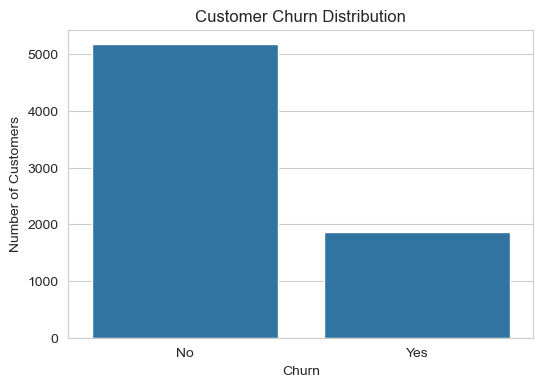

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

2. Churn by Contract Type
Count plot of Contract with Churn as the hue.
Business insight: Customers on month-to-month contracts often churn more than those on longer contracts.

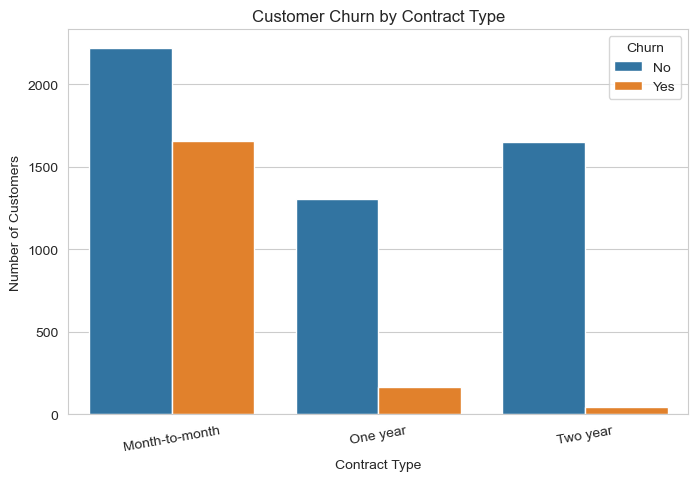

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=10)
plt.show()

3. Churn by Payment Method
Count plot of PaymentMethod with Churn as the hue.
Business insight: Compare churn across payment methods.

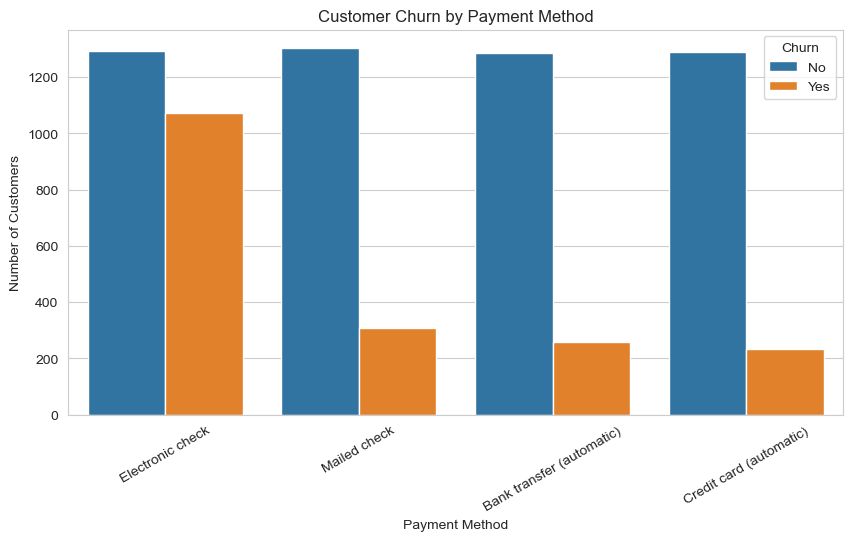

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

4. Churn by Internet Service
Count plot of InternetService with Churn as the hue.
Business insight: Identify which internet service category experiences higher churn.

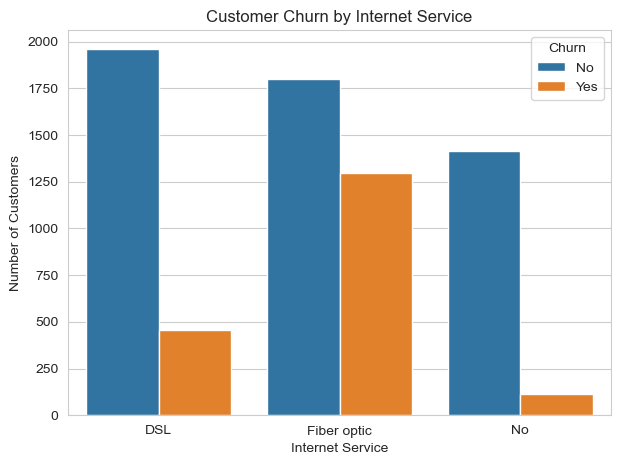

In [23]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

5. Monthly Charges Distribution
Histogram of MonthlyCharges.
Business insight: Understand the spread of monthly charges.

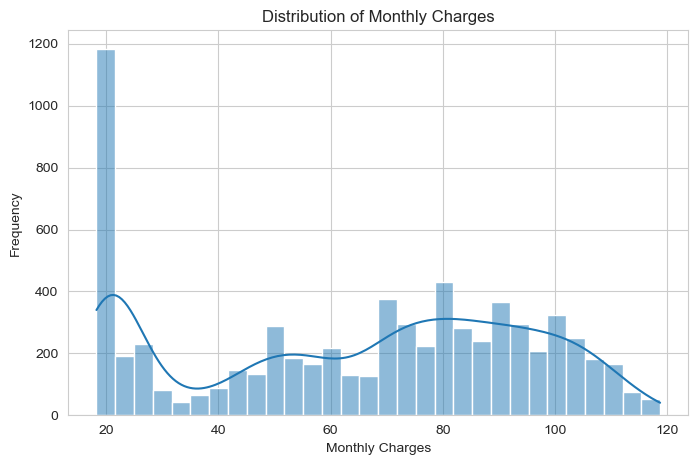

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

6. Tenure Distribution
Histogram of tenure.
Business insight: Determine whether newer customers churn more frequently.

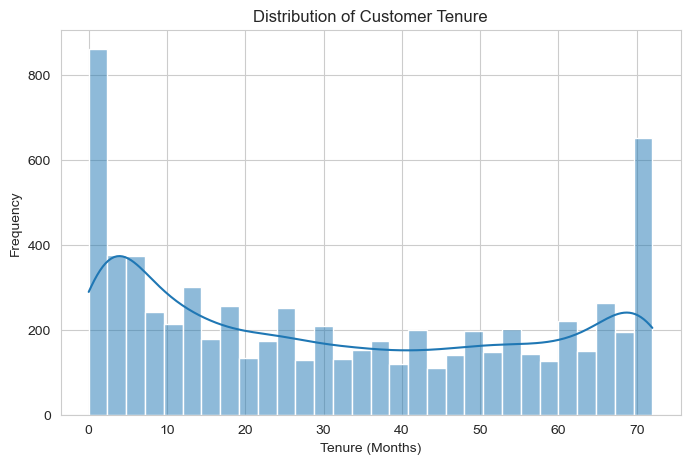

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")
plt.show()

7. Correlation Heatmap

Create a heatmap using numeric variables, including your engineered features where appropriate.

Business insight: Identify which numeric features have stronger relationships.

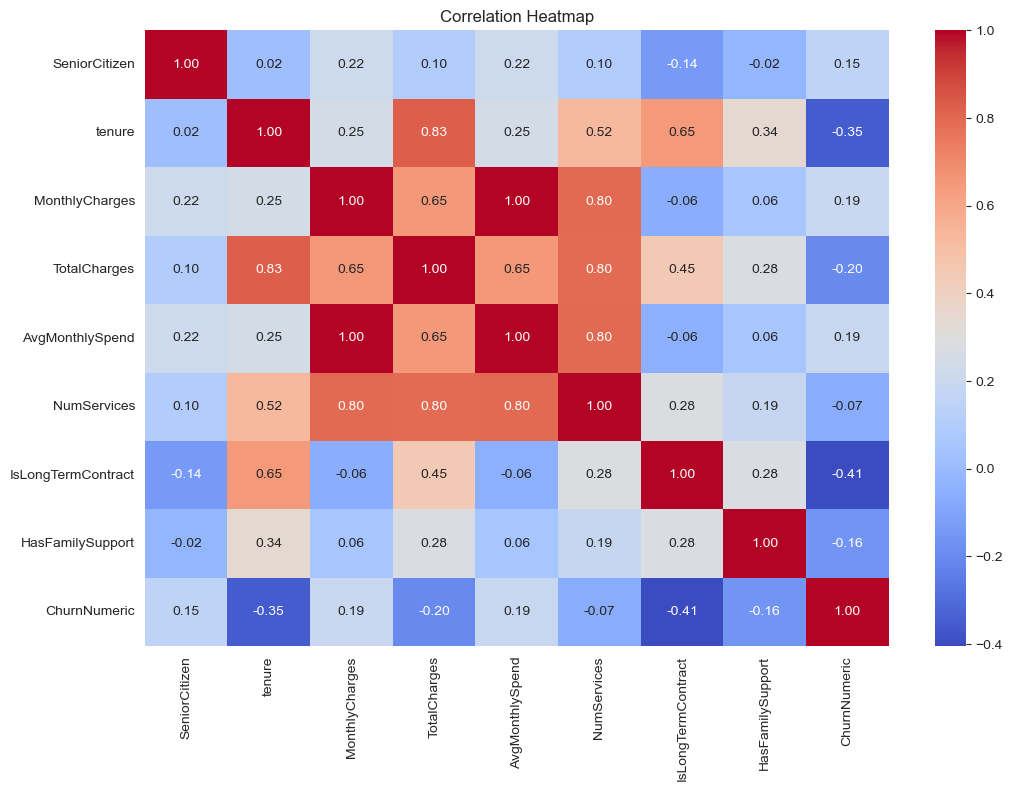

In [26]:
df["ChurnNumeric"] = df["Churn"].map({"No":0,"Yes":1})

numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

8. Churn by Number of Services

Use your NumServices feature.

Business insight: Examine whether customers with more subscribed services are less likely to churn.

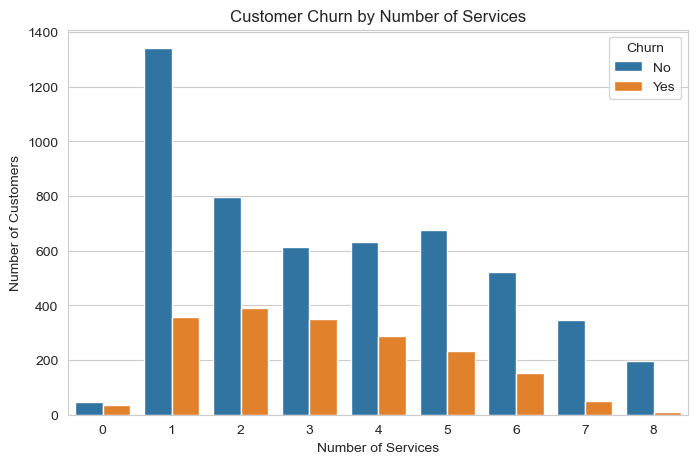

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="NumServices", hue="Churn")
plt.title("Customer Churn by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Number of Customers")
plt.show()

9. Monthly Charges vs Churn

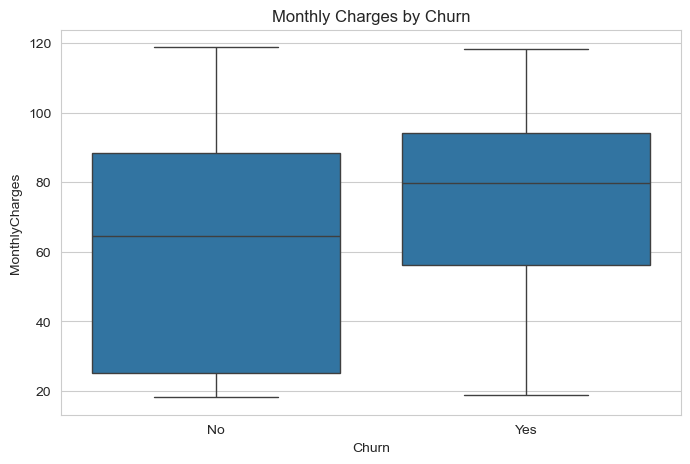

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.show()

10. Tenure vs Churn

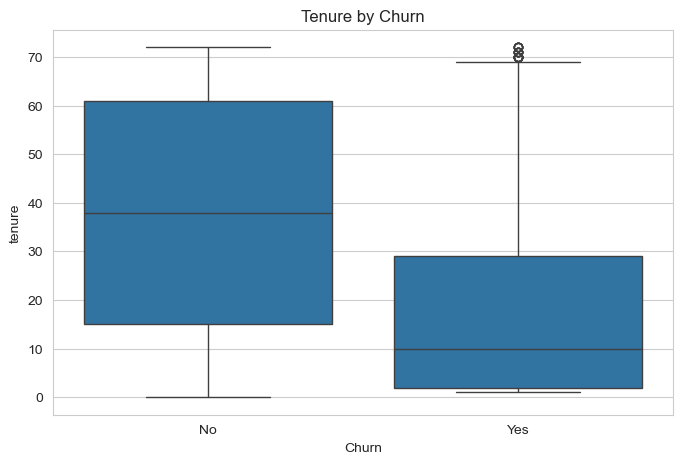

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn")
plt.show()

11. Churn by Gender

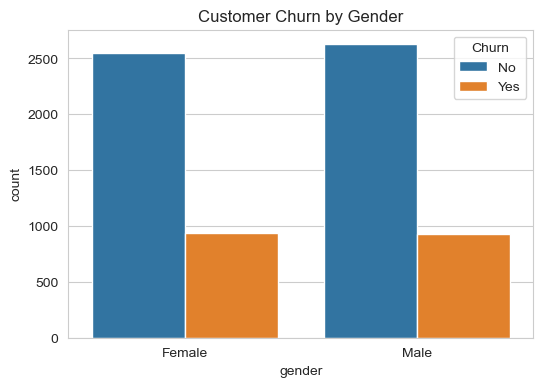

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Customer Churn by Gender")
plt.show()

12. Churn by Senior Citizen

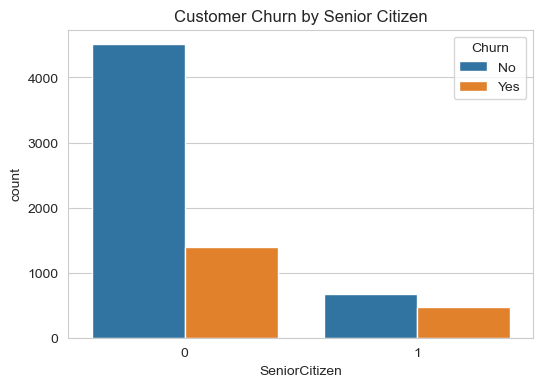

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("Customer Churn by Senior Citizen")
plt.show()

## Key Findings

- Customers on month-to-month contracts exhibit a higher churn rate than those on one-year or two-year contracts.
- Customers with shorter tenure are more likely to churn.
- Higher monthly charges are associated with increased churn.
- Customers subscribing to more services generally have lower churn rates.
- Long-term contracts appear to improve customer retention.
- Payment method and internet service type also show noticeable differences in churn behavior.

#### Model Training

#### Prepare the data

Separate features and target:


In [32]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

##### Encode categorical variables

In [33]:
X = pd.get_dummies(X, drop_first=True)

##### Encode the target

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

#### Split the dataset

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Train Logistic Regression

In [36]:
X_train.isna().sum()[X_train.isna().sum() > 0]

TotalCharges       8
AvgMonthlySpend    8
dtype: int64

In [37]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [38]:
df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"].replace(0, 1)
df["AvgMonthlySpend"] = df["AvgMonthlySpend"].fillna(0)

In [39]:
X = df.drop(["Churn", "ChurnNumeric"], axis=1)
X = pd.get_dummies(X, drop_first=True)

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

print(X.isna().sum()[X.isna().sum() > 0])

Series([], dtype: int64)


In [40]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = df.drop(["Churn", "ChurnNumeric"], axis=1)
X = pd.get_dummies(X, drop_first=True)
X = pd.get_dummies(X, drop_first=True)

y = LabelEncoder().fit_transform(df["Churn"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

c:\Users\HP\miniconda3\envs\python_ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Train Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
print(X.columns[:10])
print("customerID" in X.columns)

print(X.shape)

corr = df.select_dtypes(include="number").corr()
print(df[["Churn", "ChurnNumeric"]].head(10))

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'AvgMonthlySpend', 'NumServices', 'IsLongTermContract',
       'HasFamilySupport', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ'],
      dtype='object')
False
(7043, 7079)
  Churn  ChurnNumeric
0    No             0
1    No             0
2   Yes             1
3    No             0
4   Yes             1
5   Yes             1
6    No             0
7    No             0
8   Yes             1
9    No             0


##### Make Predictions 

In [44]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

In [45]:
import joblib

joblib.dump(rf, "../models/random_forest.pkl")

['../models/random_forest.pkl']

#### Model Evaluation

#### Import Evaluation Metrics

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

##### Evaluate Logistic Regression

In [47]:
lr_pred = lr.predict(X_test)

print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC AUC  :", roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]))

Logistic Regression Results
Accuracy : 0.7934705464868701
Precision: 0.6397306397306397
Recall   : 0.5080213903743316
F1 Score : 0.5663189269746647
ROC AUC  : 0.8390555168048774


#### Classification Report

In [48]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



#### Confusion Matrix

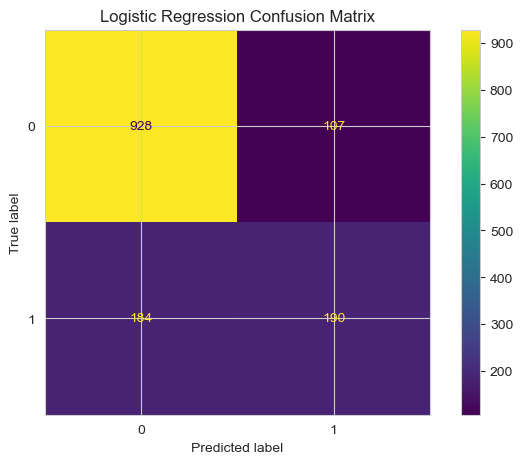

In [49]:
cm = confusion_matrix(y_test, lr_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#### Evaluate Random Forest

In [50]:
rf_pred = rf.predict(X_test)

print("Random Forest Results")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

Random Forest Results
Accuracy : 0.794180269694819
Precision: 0.6555555555555556
Recall   : 0.4732620320855615
F1 Score : 0.5496894409937888
ROC AUC  : 0.8373956960913482


#### Random Forest Classification Report

In [51]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



#### Random Forest Confusion Matrix

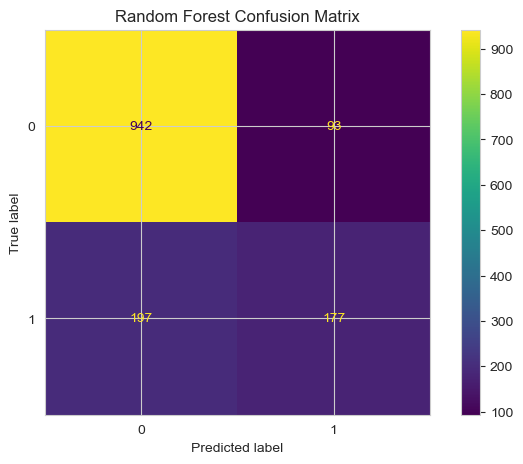

In [52]:
cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

#### Compare the Models

In [53]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.793471,0.639731,0.508021,0.566319,0.839056
1,Random Forest,0.794180,0.655556,0.473262,0.549689,0.837396


## Model Evaluation Summary

- Both models were evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix.
- Logistic Regression provides a strong baseline and is easy to interpret.
- Random Forest captures more complex relationships and may perform better depending on the evaluation metrics.
- The final model can be selected based on the business objective, such as maximizing recall to identify as many potential churners as possible.

In [54]:
import sys
from pathlib import Path
import subprocess

root = Path.cwd().parent
script_path = root / "src" / "torch_trainer.py"
print(f"Running trainer from {script_path}")
subprocess.run([sys.executable, str(script_path)], check=True)


Running trainer from c:\Users\HP\Desktop\Telco-Customer-Churn-Prediction-Model\src\torch_trainer.py


CompletedProcess(args=['c:\\Users\\HP\\miniconda3\\envs\\python_ml\\python.exe', 'c:\\Users\\HP\\Desktop\\Telco-Customer-Churn-Prediction-Model\\src\\torch_trainer.py'], returncode=0)